# Module 6 - Final Data Science Project 🎓

## Student Academic Survival & Dropout Prediction

### Project Objective

The objective of this project is to analyze student academic data and
identify factors associated with academic performance and dropout.

The project includes:

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Feature Preparation
- Machine Learning
- Student Dropout Prediction
- Model Evaluation

The final goal is to build a Machine Learning model that predicts
whether a student may drop out in the next semester.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Dataset Loading and Overview

The dataset is loaded and inspected to understand its structure, columns, data types, summary statistics, missing values, and duplicate records.


In [2]:
df = pd.read_csv("academic_survival_longitudinal.csv")

df.head()

,Student_ID,Age,Gender,First_Generation,Family_Income,Household_Size,Housing_Status,Scholarship,Tuition_Base,Semester,...,Emergency_Expense,Sem_GPA,Attendance,LMS_Logins,Advising_Visits,Failed_Courses,Financial_Stress,Target_Dropout_Next_Sem,End_of_Semester_Status,Censored
0,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,1,...,0.0,2.85,85.8,67.0,0,0,1.7,0,Enrolled,0
1,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,2,...,0.0,2.73,81.0,89.0,1,0,3.1,0,Enrolled,0
2,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,3,...,0.0,2.60,78.3,60.0,0,2,3.0,0,Enrolled,0
3,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,4,...,0.0,2.34,77.2,59.0,2,3,5.1,0,Enrolled,0
4,STU_00001,18,Female,0,15000.0,2,Off-Campus,0,15000,5,...,0.0,1.90,79.3,53.0,1,2,3.6,0,Enrolled,1


In [3]:
df.head()
df.shape


(79239, 22)

In [4]:

df.columns


Index(['Student_ID', 'Age', 'Gender', 'First_Generation', 'Family_Income',
       'Household_Size', 'Housing_Status', 'Scholarship', 'Tuition_Base',
       'Semester', 'Course_Load', 'Work_Hours', 'Emergency_Expense', 'Sem_GPA',
       'Attendance', 'LMS_Logins', 'Advising_Visits', 'Failed_Courses',
       'Financial_Stress', 'Target_Dropout_Next_Sem', 'End_of_Semester_Status',
       'Censored'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 79239 entries, 0 to 79238
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Student_ID               79239 non-null  str    
 1   Age                      79239 non-null  int64  
 2   Gender                   79239 non-null  str    
 3   First_Generation         79239 non-null  int64  
 4   Family_Income            75635 non-null  float64
 5   Household_Size           79239 non-null  int64  
 6   Housing_Status           79239 non-null  str    
 7   Scholarship              79239 non-null  int64  
 8   Tuition_Base             79239 non-null  int64  
 9   Semester                 79239 non-null  int64  
 10  Course_Load              79239 non-null  int64  
 11  Work_Hours               79239 non-null  float64
 12  Emergency_Expense        79239 non-null  float64
 13  Sem_GPA                  79239 non-null  float64
 14  Attendance               79239 no

In [6]:
df.describe()

,Age,First_Generation,Family_Income,Household_Size,Scholarship,Tuition_Base,Semester,Course_Load,Work_Hours,Emergency_Expense,Sem_GPA,Attendance,LMS_Logins,Advising_Visits,Failed_Courses,Financial_Stress,Target_Dropout_Next_Sem,Censored
count,79239.000000,79239.000000,75635.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000,78372.000000,79239.000000,79239.000000,79239.000000,79239.000000,79239.000000
mean,19.492005,0.327894,61518.384346,3.187547,0.277515,24775.110741,3.145673,14.888615,16.936129,200.496788,2.691463,85.081599,66.375670,0.477530,0.652494,2.578287,0.087293,0.140272
std,2.139140,0.469449,39661.166570,1.332861,0.447775,10794.899387,1.946207,2.307308,10.724479,724.400513,0.422692,6.415864,12.730793,0.671954,0.786066,1.817880,0.282266,0.347271
min,17.000000,0.000000,3000.000000,1.000000,0.000000,15000.000000,1.000000,9.000000,0.000000,0.000000,0.440000,-2.000000,12.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,18.000000,0.000000,35000.000000,2.000000,0.000000,15000.000000,1.000000,12.000000,8.300000,0.000000,2.440000,81.200000,58.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,19.000000,0.000000,52000.000000,3.000000,0.000000,25000.000000,3.000000,15.000000,16.500000,0.000000,2.700000,85.200000,66.000000,0.000000,0.000000,2.100000,0.000000,0.000000
75%,21.000000,1.000000,77000.000000,4.000000,1.000000,25000.000000,4.000000,15.000000,24.900000,0.000000,2.960000,89.200000,75.000000,1.000000,1.000000,3.400000,0.000000,0.000000
max,37.000000,1.000000,488000.000000,6.000000,1.000000,45000.000000,8.000000,21.000000,40.000000,3998.000000,3.960000,105.000000,116.000000,3.000000,5.000000,18.600000,1.000000,1.000000


## 2. Data Cleaning

The dataset is checked for missing values and duplicates. Missing values in `Family_Income` and `LMS_Logins` are imputed using their median values.


In [7]:
df.isnull().sum()

Student_ID                    0
Age                           0
Gender                        0
First_Generation              0
Family_Income              3604
Household_Size                0
Housing_Status                0
Scholarship                   0
Tuition_Base                  0
Semester                      0
Course_Load                   0
Work_Hours                    0
Emergency_Expense             0
Sem_GPA                       0
Attendance                    0
LMS_Logins                  867
Advising_Visits               0
Failed_Courses                0
Financial_Stress              0
Target_Dropout_Next_Sem       0
End_of_Semester_Status        0
Censored                      0
dtype: int64

In [12]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [20]:
print("Family Income Median:", df["Family_Income"].median())
print("LMS Logins Median:", df["LMS_Logins"].median())

Family Income Median: 52000.0
LMS Logins Median: 66.0


In [22]:
df["Family_Income"] = df["Family_Income"].fillna(
    df["Family_Income"].median()
)

df["LMS_Logins"] = df["LMS_Logins"].fillna(
    df["LMS_Logins"].median()
)

In [23]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


## Handling Missing Values

The dataset was checked for missing values.

Missing values were found in:

- `Family_Income`
- `LMS_Logins`

The missing values were filled using the median of their respective
columns. Median imputation was used as a simple approach that is less
sensitive to extreme values than the mean.

After imputation, the dataset was checked again to confirm that no
missing values remained.

## 3. Target Variable Analysis

The distribution of `Target_Dropout_Next_Sem` is examined before modeling because class imbalance can strongly affect evaluation.


In [13]:
df["Target_Dropout_Next_Sem"].value_counts()

Target_Dropout_Next_Sem
0    72322
1     6917
Name: count, dtype: int64

In [14]:
df["Target_Dropout_Next_Sem"].value_counts(normalize=True) * 100

Target_Dropout_Next_Sem
0    91.270713
1     8.729287
Name: proportion, dtype: float64

### Target Distribution

The target variable is highly imbalanced.

- Class 0: 72,322 records (91.27%)
- Class 1: 6,917 records (8.73%)

Because one class represents the majority of the dataset, model
performance should not be evaluated using accuracy alone.

Metrics such as precision, recall, F1-score, and the confusion matrix
will also be used to evaluate the classification model.

In [27]:
df[[
    "Age",
    "Family_Income",
    "Course_Load",
    "Work_Hours",
    "Sem_GPA",
    "Attendance",
    "LMS_Logins",
    "Advising_Visits",
    "Failed_Courses",
    "Financial_Stress"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,79239.0,19.492005,2.139140,17.00,18.00,19.0,21.00,37.00
Family_Income,79239.0,61085.462966,38799.432822,3000.00,35000.00,52000.0,75000.00,488000.00
Course_Load,79239.0,14.888615,2.307308,9.00,12.00,15.0,15.00,21.00
Work_Hours,79239.0,16.936129,10.724479,0.00,8.30,16.5,24.90,40.00
Sem_GPA,79239.0,2.691463,0.422692,0.44,2.44,2.7,2.96,3.96
Attendance,79239.0,85.081599,6.415864,-2.00,81.20,85.2,89.20,105.00
LMS_Logins,79239.0,66.371559,12.661013,12.00,58.00,66.0,75.00,116.00
Advising_Visits,79239.0,0.477530,0.671954,0.00,0.00,0.0,1.00,3.00
Failed_Courses,79239.0,0.652494,0.786066,0.00,0.00,0.0,1.00,5.00
Financial_Stress,79239.0,2.578287,1.817880,1.00,1.00,2.1,3.40,18.60


## 4. Exploratory Data Analysis

In this section, different academic factors are compared with the
target variable `Target_Dropout_Next_Sem`.

The analysis focuses on identifying patterns and differences between
the target classes before building the Machine Learning model.

In [28]:
gpa_by_dropout = df.groupby(
    "Target_Dropout_Next_Sem"
)["Sem_GPA"].mean()

print(gpa_by_dropout)



Target_Dropout_Next_Sem
0    2.724572
1    2.345288
Name: Sem_GPA, dtype: float64


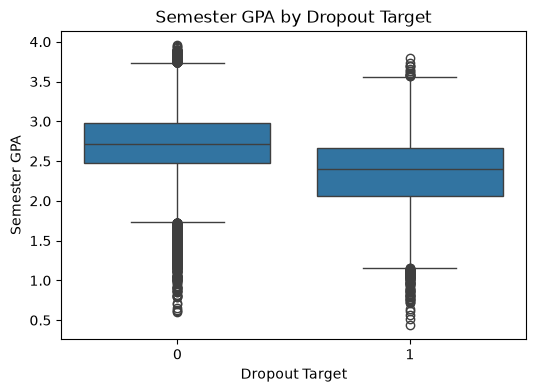

In [29]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="Target_Dropout_Next_Sem",
    y="Sem_GPA"
)

plt.title("Semester GPA by Dropout Target")
plt.xlabel("Dropout Target")
plt.ylabel("Semester GPA")

plt.show()

In [30]:
attendance_by_dropout = df.groupby(
    "Target_Dropout_Next_Sem"
)["Attendance"].mean()

print(attendance_by_dropout)

Target_Dropout_Next_Sem
0    85.258522
1    83.231748
Name: Attendance, dtype: float64


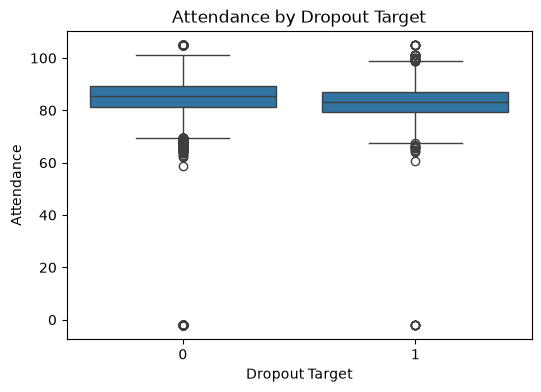

In [35]:
plt.figure(figsize=(6, 4))

sns.boxplot(
    data=df,
    x="Target_Dropout_Next_Sem",
    y="Attendance"
)

plt.title("Attendance by Dropout Target")
plt.xlabel("Dropout Target")
plt.ylabel("Attendance")

plt.show()

### Attendance Observation

Students in target class 1 had a slightly lower average attendance
(83.23) compared with students in target class 0 (85.26).

This indicates that attendance has some association with the dropout
target, although the difference between the two groups is relatively small.

## Failed Courses vs Target

In [36]:
failed_by_dropout = df.groupby(
    "Target_Dropout_Next_Sem"
)["Failed_Courses"].mean()

print(failed_by_dropout)

Target_Dropout_Next_Sem
0    0.599970
1    1.201677
Name: Failed_Courses, dtype: float64


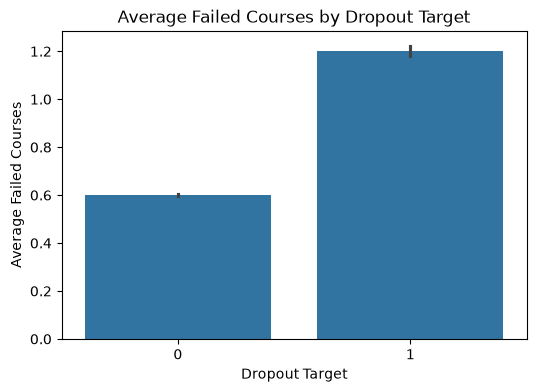

In [37]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=df,
    x="Target_Dropout_Next_Sem",
    y="Failed_Courses"
)

plt.title("Average Failed Courses by Dropout Target")
plt.xlabel("Dropout Target")
plt.ylabel("Average Failed Courses")

plt.show()

### Failed Courses Observation

Students in target class 1 had an average of 1.20 failed courses,
compared with 0.60 failed courses for students in target class 0.

This shows a clear association between the number of failed courses
and the dropout target. Failed courses may therefore be an important
feature for predicting student dropout.

## Financial Stress vs Dropout 💰

In [38]:
stress_by_dropout = df.groupby(
    "Target_Dropout_Next_Sem"
)["Financial_Stress"].mean()

print(stress_by_dropout)

Target_Dropout_Next_Sem
0    2.454519
1    3.872372
Name: Financial_Stress, dtype: float64


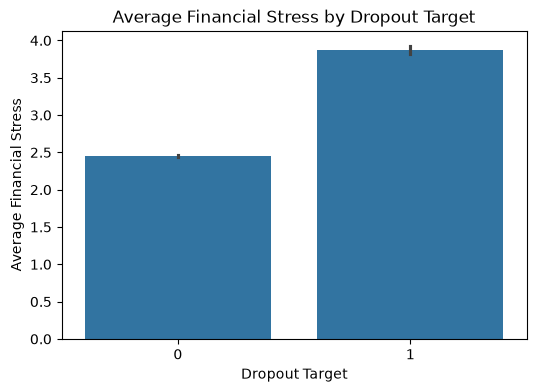

In [39]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=df,
    x="Target_Dropout_Next_Sem",
    y="Financial_Stress"
)

plt.title("Average Financial Stress by Dropout Target")
plt.xlabel("Dropout Target")
plt.ylabel("Average Financial Stress")

plt.show()

### Financial Stress Observation

Students in target class 1 had a higher average financial stress
score (3.87) compared with students in target class 0 (2.45).

This indicates a strong association between financial stress and the
dropout target. Financial stress may therefore be an important feature
for predicting student dropout.

## Work Hours vs Dropout 💼

In [41]:
work_by_dropout = df.groupby(
    "Target_Dropout_Next_Sem"
)["Work_Hours"].mean()

print(work_by_dropout)

Target_Dropout_Next_Sem
0    16.519759
1    21.289562
Name: Work_Hours, dtype: float64


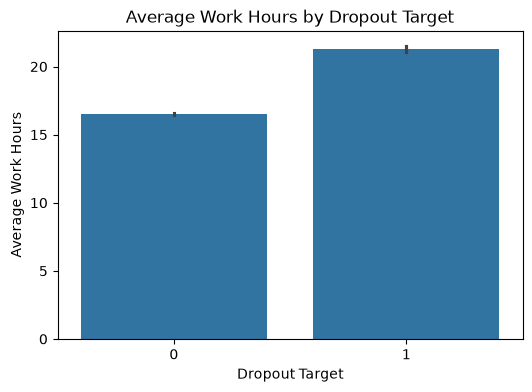

In [42]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=df,
    x="Target_Dropout_Next_Sem",
    y="Work_Hours"
)

plt.title("Average Work Hours by Dropout Target")
plt.xlabel("Dropout Target")
plt.ylabel("Average Work Hours")

plt.show()

### Work Hours Observation

Students in target class 1 had higher average work hours than students in target class 0. This indicates an association between workload and the target, but it should not be interpreted as a causal relationship.


## LMS Logins vs Target 💻

In [43]:
lms_by_dropout = df.groupby(
    "Target_Dropout_Next_Sem"
)["LMS_Logins"].mean()

print(lms_by_dropout)

Target_Dropout_Next_Sem
0    66.708097
1    62.852826
Name: LMS_Logins, dtype: float64


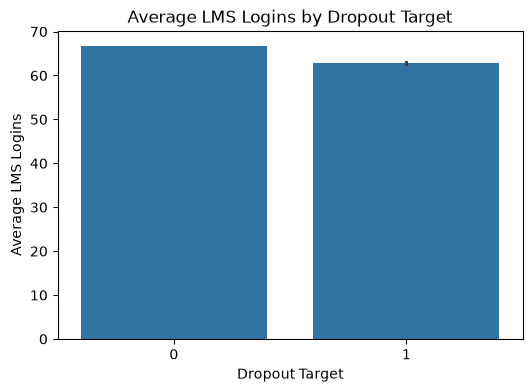

In [44]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=df,
    x="Target_Dropout_Next_Sem",
    y="LMS_Logins"
)

plt.title("Average LMS Logins by Dropout Target")
plt.xlabel("Dropout Target")
plt.ylabel("Average LMS Logins")

plt.show()

### LMS Login Observation

Students in target class 1 had an average of 62.85 LMS logins,
compared with 66.71 LMS logins for students in target class 0.

This shows that target class 1 had slightly lower LMS engagement.
LMS activity may therefore provide useful information for predicting
the dropout target.

## Advising Visits vs Target

In [45]:
advising_by_dropout = df.groupby(
    "Target_Dropout_Next_Sem"
)["Advising_Visits"].mean()

print(advising_by_dropout)

Target_Dropout_Next_Sem
0    0.463206
1    0.627295
Name: Advising_Visits, dtype: float64


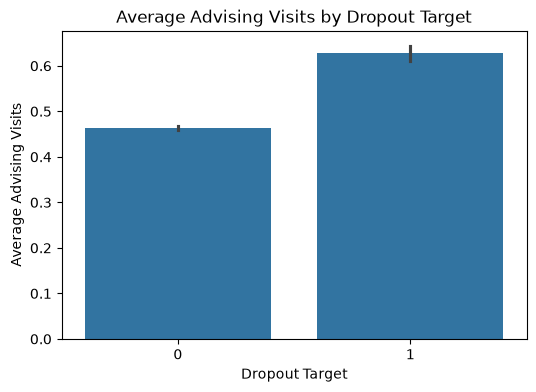

In [46]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=df,
    x="Target_Dropout_Next_Sem",
    y="Advising_Visits"
)

plt.title("Average Advising Visits by Dropout Target")
plt.xlabel("Dropout Target")
plt.ylabel("Average Advising Visits")

plt.show()

### Advising Visits Observation

Students in target class 1 had an average of 0.63 advising visits,
compared with 0.46 visits for students in target class 0.

This indicates that advising visits differ between the two target
groups. However, this analysis only shows an association and does not
explain why students in class 1 had more advising visits.

## Scholarship vs Target 🎓

In [47]:
print(df["Scholarship"].value_counts())

Scholarship
0    57249
1    21990
Name: count, dtype: int64


In [48]:
scholarship_dropout = pd.crosstab(
    df["Scholarship"],
    df["Target_Dropout_Next_Sem"],
    normalize="index"
) * 100

print(scholarship_dropout)

Target_Dropout_Next_Sem          0         1
Scholarship                                 
0                        90.315988  9.684012
1                        93.756253  6.243747


### Scholarship Observation

Students with Scholarship = 0 had 9.68% of records in target class 1,
while students with Scholarship = 1 had 6.24% in target class 1.

This indicates an association between scholarship status and the
dropout target. The group with Scholarship = 1 had a lower proportion
of target class 1 than the group with Scholarship = 0.

## First Generation Status 👨‍🎓

In [49]:
print(df["First_Generation"].value_counts())

First_Generation
0    53257
1    25982
Name: count, dtype: int64


In [50]:
first_gen_dropout = pd.crosstab(
    df["First_Generation"],
    df["Target_Dropout_Next_Sem"],
    normalize="index"
) * 100

print(first_gen_dropout)

Target_Dropout_Next_Sem          0          1
First_Generation                             
0                        92.769026   7.230974
1                        88.199523  11.800477


### First Generation Observation

Students with First_Generation = 1 had 11.80% of records in target
class 1, compared with 7.23% for students with First_Generation = 0.

This indicates an association between first-generation status and the
dropout target. First-generation status may therefore provide useful
information for the Machine Learning model.

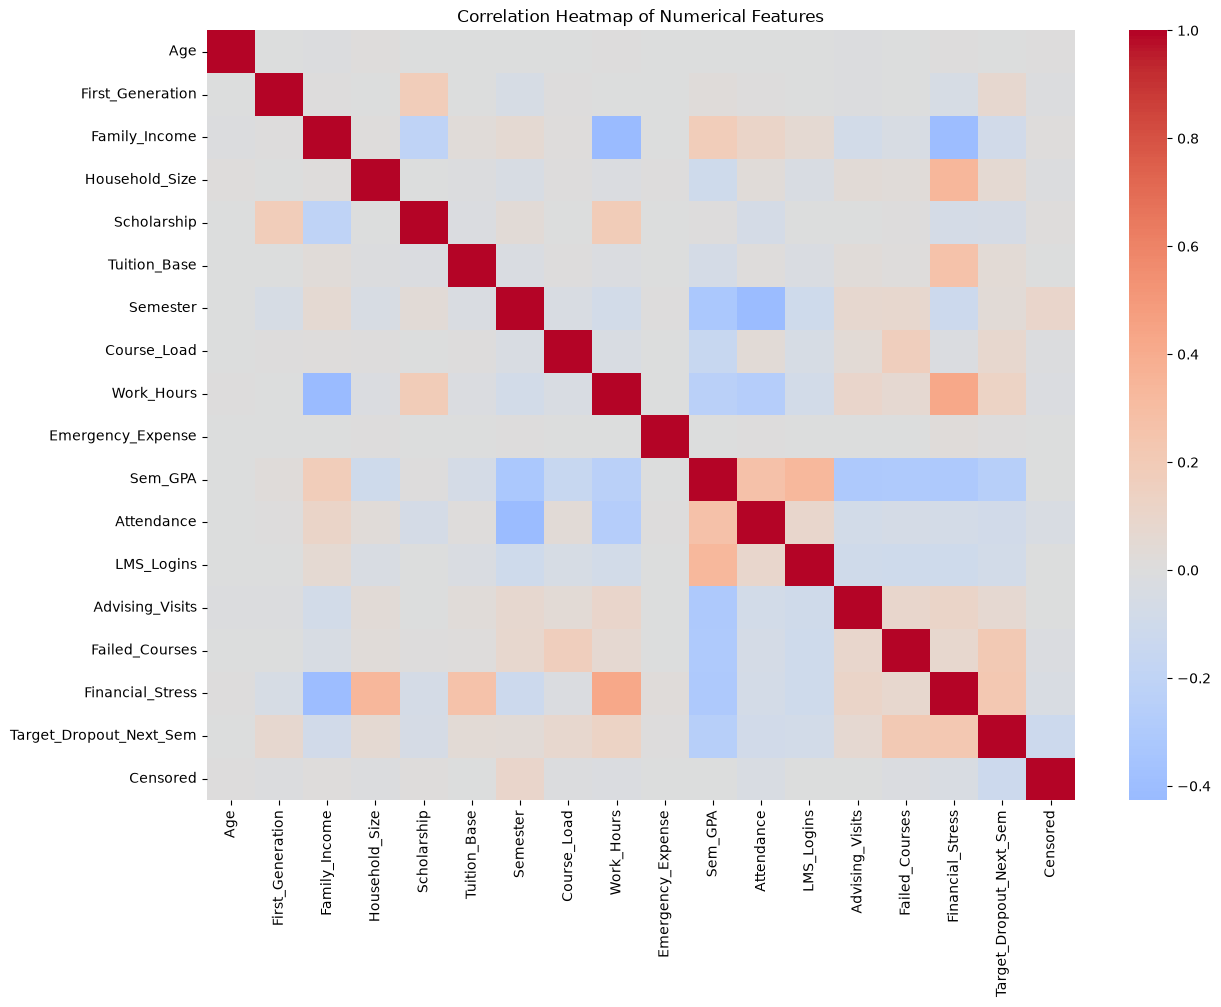

In [51]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

In [52]:
target_correlation = numeric_df.corr()["Target_Dropout_Next_Sem"]

target_correlation = target_correlation.sort_values(
    ascending=False
)

print(target_correlation)

Target_Dropout_Next_Sem    1.000000
Financial_Stress           0.220153
Failed_Courses             0.216065
Work_Hours                 0.125540
Course_Load                0.082655
First_Generation           0.075998
Advising_Visits            0.068928
Household_Size             0.058694
Tuition_Base               0.043429
Semester                   0.032998
Emergency_Expense          0.003120
Age                       -0.000840
Scholarship               -0.054575
LMS_Logins                -0.085950
Attendance                -0.089168
Family_Income             -0.091251
Censored                  -0.124919
Sem_GPA                   -0.253278
Name: Target_Dropout_Next_Sem, dtype: float64


### Correlation Analysis Observation

The correlation analysis showed that several numerical features are
associated with the dropout target.

The strongest relationships with the target included:

- Semester GPA: -0.253
- Financial Stress: 0.220
- Failed Courses: 0.216
- Work Hours: 0.126

Semester GPA had the strongest negative correlation with the target,
while Financial Stress and Failed Courses had the strongest positive
correlations.

These correlations show associations between variables and should not
be interpreted as proof of causation.

## 5. Machine Learning Model Preparation

In this section, the dataset is prepared for building a Machine Learning
model to predict the `Target_Dropout_Next_Sem` variable.

The preparation includes:

- Separating the input features (X) and target variable (y)
- Removing unnecessary or potentially leakage-prone columns
- Identifying numerical and categorical features
- Encoding categorical variables
- Splitting the dataset into training and testing sets
- Training and evaluating the classification model

The goal is to build a model that can identify patterns associated with
the student dropout target.

### Feature and Target Selection

`X` contains the input features that will be provided to the Machine
Learning model.

`y` contains the target variable that the model will learn to predict.

`Student_ID` is excluded because it is an identifier rather than a
meaningful predictive feature. `End_of_Semester_Status` and `Censored`
are also excluded to avoid potentially using outcome-related information
when predicting the target.

In [7]:
X = df.drop(
    columns=[
        "Student_ID",
        "Target_Dropout_Next_Sem",
        "End_of_Semester_Status",
        "Censored"
    ]
)

y = df["Target_Dropout_Next_Sem"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (79239, 18)
y shape: (79239,)


In [8]:
categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns

print("Categorical Columns:")
print(categorical_columns)

Categorical Columns:
Index(['Gender', 'Housing_Status'], dtype='str')


In [9]:
numerical_columns = X.select_dtypes(
    include=["number"]
).columns

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['Age', 'First_Generation', 'Family_Income', 'Household_Size',
       'Scholarship', 'Tuition_Base', 'Semester', 'Course_Load', 'Work_Hours',
       'Emergency_Expense', 'Sem_GPA', 'Attendance', 'LMS_Logins',
       'Advising_Visits', 'Failed_Courses', 'Financial_Stress'],
      dtype='str')


### Identifying Feature Types

The input features are separated into categorical and numerical
features.

This step is necessary because categorical variables must be converted
into a numerical format before they can be used by the Machine Learning
model.

In [10]:
print("Gender values:")
print(X["Gender"].value_counts())

print("\nHousing Status values:")
print(X["Housing_Status"].value_counts())

Gender values:
Gender
Female               38035
Male                 36556
Other                 1125
female                 875
male                   764
M                      739
F                      716
Prefer not to say      429
Name: count, dtype: int64

Housing Status values:
Housing_Status
On-Campus       31315
With Parents    24767
Off-Campus      23157
Name: count, dtype: int64


In [11]:
X["Gender"] = X["Gender"].replace({
    "female": "Female",
    "F": "Female",
    "male": "Male",
    "M": "Male"
})

print(X["Gender"].value_counts())

Gender
Female               39626
Male                 38059
Other                 1125
Prefer not to say      429
Name: count, dtype: int64


### Cleaning Categorical Features

The `Gender` column contained inconsistent labels such as `Female`,
`female`, and `F`, as well as `Male`, `male`, and `M`.

These values were standardized into consistent categories before
encoding. The `Housing_Status` categories were already consistent.

In [14]:
X_encoded = pd.get_dummies(
    X,
    columns=["Gender", "Housing_Status"],
    drop_first=True,
    dtype=int
)

print("Original X shape:", X.shape)
print("Encoded X shape:", X_encoded.shape)

X_encoded.head()

Original X shape: (79239, 18)
Encoded X shape: (79239, 21)


,Age,First_Generation,Family_Income,Household_Size,Scholarship,Tuition_Base,Semester,Course_Load,Work_Hours,Emergency_Expense,...,Attendance,LMS_Logins,Advising_Visits,Failed_Courses,Financial_Stress,Gender_Male,Gender_Other,Gender_Prefer not to say,Housing_Status_On-Campus,Housing_Status_With Parents
0,18,0,15000.0,2,0,15000,1,15,18.4,0.0,...,85.8,67.0,0,0,1.7,0,0,0,0,0
1,18,0,15000.0,2,0,15000,2,15,23.1,0.0,...,81.0,89.0,1,0,3.1,0,0,0,0,0
2,18,0,15000.0,2,0,15000,3,15,19.1,0.0,...,78.3,60.0,0,2,3.0,0,0,0,0,0
3,18,0,15000.0,2,0,15000,4,15,26.5,0.0,...,77.2,59.0,2,3,5.1,0,0,0,0,0
4,18,0,15000.0,2,0,15000,5,18,25.4,0.0,...,79.3,53.0,1,2,3.6,0,0,0,0,0


### Encoding Categorical Features

The categorical features `Gender` and `Housing_Status` were converted
into numerical features using One-Hot Encoding.

One category from each feature was dropped to avoid redundant dummy
variables. The encoded dataset can now be used for Machine Learning.

### Longitudinal Structure Check

Because the dataset contains repeated semester records for the same students, the number of unique `Student_ID` values is checked before splitting the data.


In [16]:
print("Total rows:", len(df))
print("Unique students:", df["Student_ID"].nunique())

print("\nNumber of records per student:")
print(df["Student_ID"].value_counts().head(10))

Total rows: 79239
Unique students: 20000

Number of records per student:
Student_ID
STU_00018    8
STU_00023    8
STU_00042    8
STU_00054    8
STU_00060    8
STU_00076    8
STU_00077    8
STU_00079    8
STU_00081    8
STU_00099    8
Name: count, dtype: int64


### Group-Based Train-Test Split

Since the dataset contains multiple semester records for the same
students, a group-based train-test split was used.

`Student_ID` was used as the grouping variable so that records belonging
to the same student are not distributed across both the training and
testing datasets.

This helps prevent data leakage and provides a more realistic evaluation
of the Machine Learning model.

In [17]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["Student_ID"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X_encoded, y, groups=groups)
)

X_train = X_encoded.iloc[train_idx]
X_test = X_encoded.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (63475, 21)
X_test shape: (15764, 21)
y_train shape: (63475,)
y_test shape: (15764,)


In [18]:
train_students = set(df.iloc[train_idx]["Student_ID"])
test_students = set(df.iloc[test_idx]["Student_ID"])

overlap = train_students.intersection(test_students)

print("Training students:", len(train_students))
print("Testing students:", len(test_students))
print("Students appearing in both:", len(overlap))

Training students: 16000
Testing students: 4000
Students appearing in both: 0


In [19]:
print("Training Target Distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting Target Distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training Target Distribution:
Target_Dropout_Next_Sem
0    91.327294
1     8.672706
Name: proportion, dtype: float64

Testing Target Distribution:
Target_Dropout_Next_Sem
0    91.042883
1     8.957117
Name: proportion, dtype: float64


### Model Training and Evaluation


### Logistic Regression

Logistic Regression was trained as a baseline classification model. Because the target variable is imbalanced, `class_weight="balanced"` was used.

The model is evaluated using accuracy, precision, recall, F1-score, and a confusion matrix, with particular attention to class 1.


In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [22]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7280512560263892

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.74      0.83     14352
           1       0.19      0.65      0.30      1412

    accuracy                           0.73     15764
   macro avg       0.57      0.69      0.57     15764
weighted avg       0.89      0.73      0.78     15764


Confusion Matrix:
[[10563  3789]
 [  498   914]]


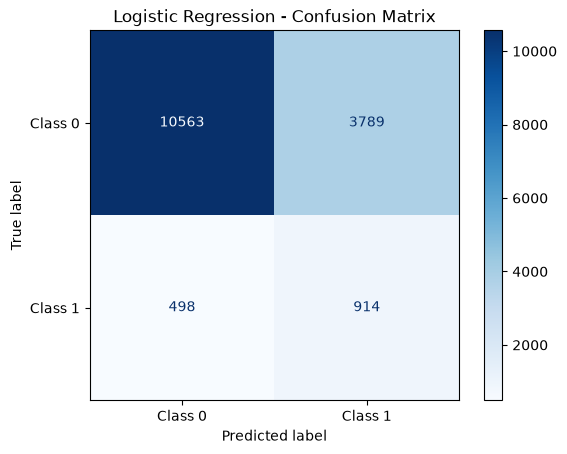

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Class 0", "Class 1"],
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

### Random Forest Classification

A Random Forest Classifier was trained as a second Machine Learning
model to compare its performance with Logistic Regression.

Balanced class weights were used because the target variable contains
significantly fewer class-1 observations than class-0 observations.

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [25]:
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions completed!")

Random Forest predictions completed!


In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.9077010910936311

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95     14352
           1       0.47      0.24      0.32      1412

    accuracy                           0.91     15764
   macro avg       0.70      0.61      0.64     15764
weighted avg       0.89      0.91      0.89     15764


Confusion Matrix:
[[13967   385]
 [ 1070   342]]


### Model Comparison

Two classification models were evaluated: Logistic Regression and
Random Forest.

Random Forest achieved higher overall accuracy and higher precision
for class 1. However, Logistic Regression achieved substantially higher
recall for class 1, identifying a larger proportion of the actual
minority-class cases.

Because the dataset is imbalanced, overall accuracy alone is not
sufficient for evaluating model performance. Precision, recall,
F1-score, and the confusion matrix were also considered.

In [27]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision (Class 1)": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall (Class 1)": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score (Class 1)": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ]
})

comparison.round(3)

,Model,Accuracy,Precision (Class 1),Recall (Class 1),F1 Score (Class 1)
0,Logistic Regression,0.728,0.194,0.647,0.299
1,Random Forest,0.908,0.470,0.242,0.320


## 6. Feature Importance


### Feature Importance

Feature importance from the Random Forest model was analyzed to identify
which input variables contributed most to the model's predictions.

Higher importance indicates that a feature was used more strongly by
the Random Forest when making predictions. Feature importance represents
predictive contribution and should not be interpreted as proof of causation.

In [28]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
10,Sem_GPA,0.156369
15,Financial_Stress,0.111601
8,Work_Hours,0.097623
11,Attendance,0.095329
2,Family_Income,0.089652
12,LMS_Logins,0.079347
14,Failed_Courses,0.069310
0,Age,0.046886
6,Semester,0.042010
3,Household_Size,0.038156


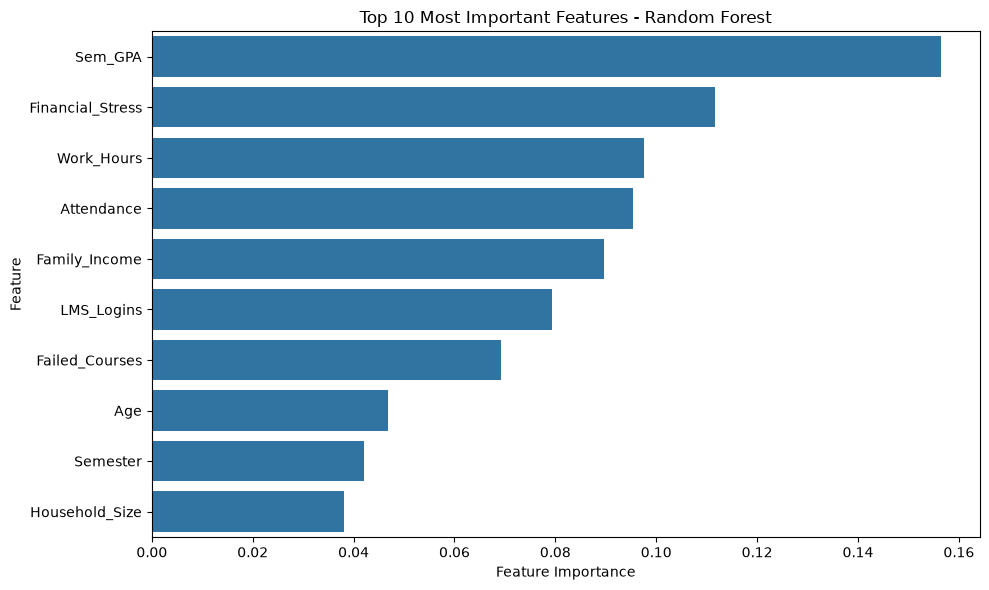

In [29]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Feature Importance Interpretation

The Random Forest feature importance analysis shows that `Sem_GPA`
was the most influential feature in the model's predictions.

Other important features included `Financial_Stress`, `Work_Hours`,
`Attendance`, `Family_Income`, `LMS_Logins`, and `Failed_Courses`.

These results suggest that the model relies on a combination of
academic, financial, engagement, and workload-related information
when making predictions.

Feature importance represents predictive contribution within the
Random Forest model and should not be interpreted as evidence that
these factors directly cause student dropout.

## 7. Results Summary

### Key Findings

The dataset contained **79,239 semester-level records from 20,000 students**. Because multiple records belonged to the same students, a group-based train-test split using `Student_ID` was used to prevent the same student from appearing in both the training and testing sets.

The target variable was imbalanced, with approximately **91% class 0** and **9% class 1** observations. Therefore, model performance was evaluated using precision, recall, F1-score, and confusion matrices in addition to accuracy.

### Model Performance

| Model | Accuracy | Precision (Class 1) | Recall (Class 1) | F1-Score (Class 1) |
|---|---:|---:|---:|---:|
| Logistic Regression | 72.8% | 0.194 | 0.647 | 0.299 |
| Random Forest | 90.8% | 0.470 | 0.242 | 0.320 |

**Logistic Regression** identified a larger proportion of actual class-1 cases, achieving a class-1 recall of **64.7%**, but it also produced more false-positive predictions.

**Random Forest** achieved much higher overall accuracy and better class-1 precision, but its class-1 recall was only **24.2%**, meaning that many actual class-1 cases were not detected.

These results show why accuracy alone is not sufficient for this imbalanced classification problem. The preferred model depends on whether the application places greater importance on detecting more at-risk cases or reducing false-positive alerts.

### Important Predictive Features

Random Forest feature importance showed that the model relied most strongly on:

1. `Sem_GPA`
2. `Financial_Stress`
3. `Work_Hours`
4. `Attendance`
5. `Family_Income`
6. `LMS_Logins`
7. `Failed_Courses`

The model therefore used a combination of academic performance, financial circumstances, workload, and engagement-related information when making predictions.

### Overall Result

The project successfully completed the full Data Science workflow: data cleaning, exploratory analysis, visualization, feature preparation, leakage-aware train-test splitting, classification modeling, model evaluation, comparison, and feature-importance analysis.

The results demonstrate that Machine Learning can identify patterns associated with the dropout target. However, the findings represent **predictive associations rather than causal relationships**, and the models would require further validation and improvement before being used in a real student-support system.


## 8. Project Conclusion

This project analyzed longitudinal student academic data to identify
patterns associated with the student dropout target and to develop
Machine Learning models for prediction.

The analysis showed meaningful differences between the target classes
in factors such as semester GPA, financial stress, failed courses,
work hours, attendance, and LMS activity.

Two classification models were evaluated:

- Logistic Regression achieved approximately 72.8% accuracy and
  64.7% recall for class 1.
- Random Forest achieved approximately 90.8% accuracy and
  24.2% recall for class 1.

Random Forest provided substantially higher overall accuracy and
higher class-1 precision, while Logistic Regression identified a
larger proportion of the actual class-1 cases.

Because the dataset is imbalanced, accuracy alone was not considered
sufficient for evaluating model performance. Precision, recall,
F1-score, and confusion matrices were also examined.

Random Forest feature importance showed that `Sem_GPA`,
`Financial_Stress`, `Work_Hours`, `Attendance`, and `Family_Income`
were among the most influential features used by the model.

Overall, the project demonstrates how data analysis and Machine
Learning can be used to identify patterns associated with academic
risk. The models should be treated as predictive tools rather than
evidence of causal relationships.
